<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension013.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

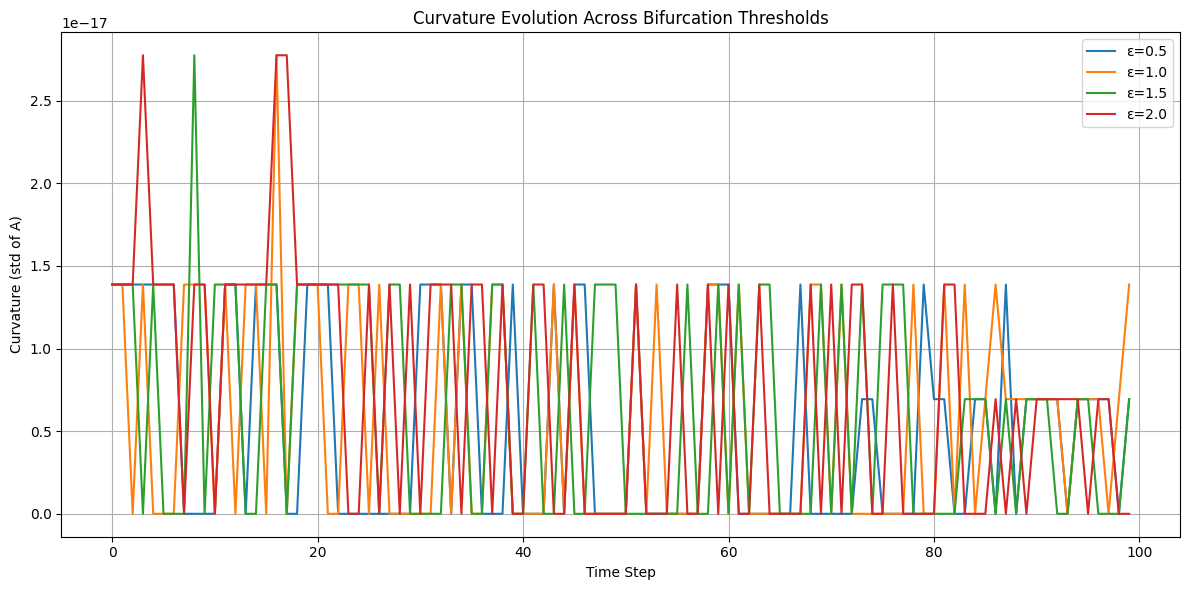

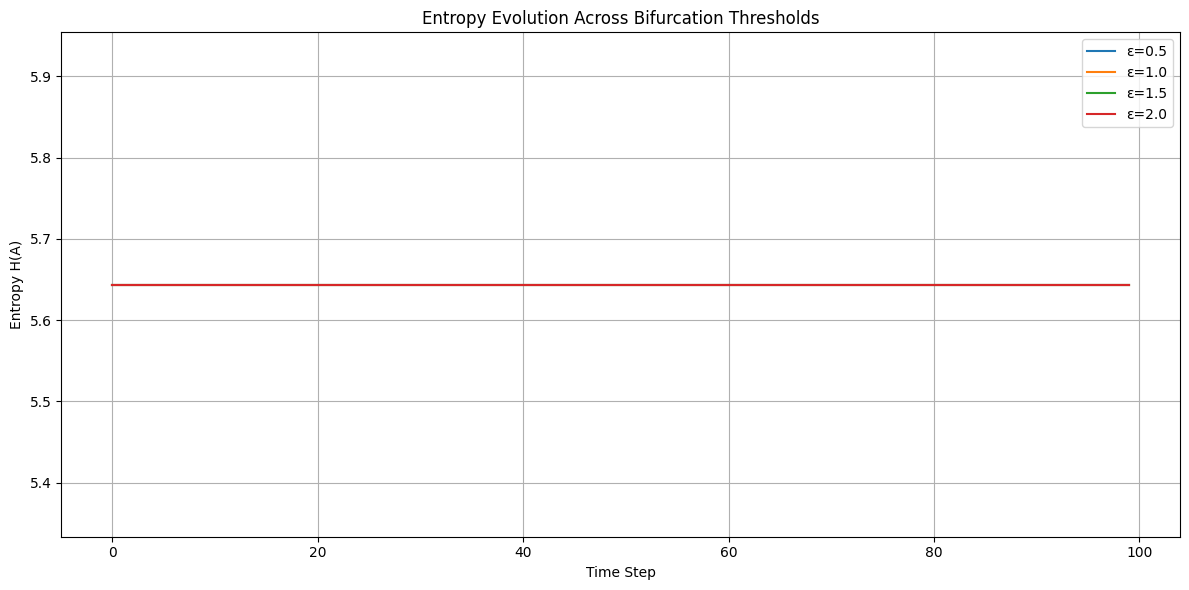

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Parameters
# -------------------------------
kappa = 0.2
delta = 0.02
gamma0 = 0.5
xi = 0.01
A0 = 0.1
time_steps = 100
grid_size = 50
epsilons = [0.5, 1.0, 1.5, 2.0]

# -------------------------------
# Evolution Function
# -------------------------------
def evolve_and_track(epsilon):
    A = np.ones(grid_size) * A0
    curvature_history = []
    entropy_history = []

    for t in range(time_steps):
        laplacian = np.roll(A, -1) - 2 * A + np.roll(A, 1)
        dA_dt = -kappa * A + delta * A**2 + epsilon * A**3 + gamma0 * laplacian + xi
        A += dA_dt * 0.1

        # Curvature: std deviation
        curvature = np.std(A)
        curvature_history.append(curvature)

        # Entropy: normalized distribution
        probs = np.abs(A) / np.sum(np.abs(A)) if np.sum(np.abs(A)) > 0 else np.zeros_like(A)
        entropy = -np.sum(probs[probs > 0] * np.log2(probs[probs > 0]))
        entropy_history.append(entropy)

    return curvature_history, entropy_history

# -------------------------------
# Run Sweep
# -------------------------------
results = {eps: evolve_and_track(eps) for eps in epsilons}

# -------------------------------
# Plot Curvature Evolution
# -------------------------------
plt.figure(figsize=(12, 6))
for eps in epsilons:
    plt.plot(results[eps][0], label=f'ε={eps}')
plt.title("Curvature Evolution Across Bifurcation Thresholds")
plt.xlabel("Time Step")
plt.ylabel("Curvature (std of A)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------
# Plot Entropy Evolution
# -------------------------------
plt.figure(figsize=(12, 6))
for eps in epsilons:
    plt.plot(results[eps][1], label=f'ε={eps}')
plt.title("Entropy Evolution Across Bifurcation Thresholds")
plt.xlabel("Time Step")
plt.ylabel("Entropy H(A)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
